# Danish Names Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import entropy as scipy_entropy

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
df = pd.read_csv("danish_female_names_data_big.csv")
years = [c for c in df.columns if c.isdigit()]
year_ints = list(map(int, years))
print(f"{len(df)} rows, {len(years)} years ({years[0]}–{years[-1]})")
df.head(3)

16851 rows, 40 years (1985–2024)


,name,gender,1985,1986,1987,1988,1989,1990,1991,1992,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Mette,K,897,760,810,765,757,727,629,647,...,6,6,9,3,0,3,0,0,0,0
1,Kim,K,4,0,12,23,14,12,9,9,...,5,0,0,3,0,0,0,0,0,0
2,Kim,M,445,400,361,295,266,223,170,180,...,0,8,0,0,0,0,0,5,0,0


## Basic plots

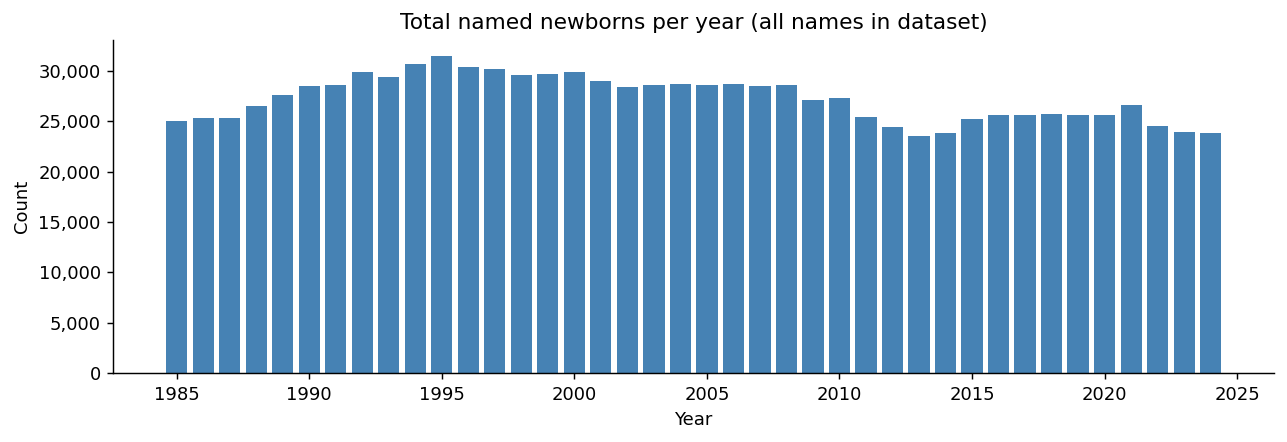

In [ ]:
# Total births per year across all names & genders
total_per_year = df[years].sum()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(year_ints, total_per_year.values, color="steelblue", width=0.8)
ax.set_title("Total named newborns per year (all names in dataset)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

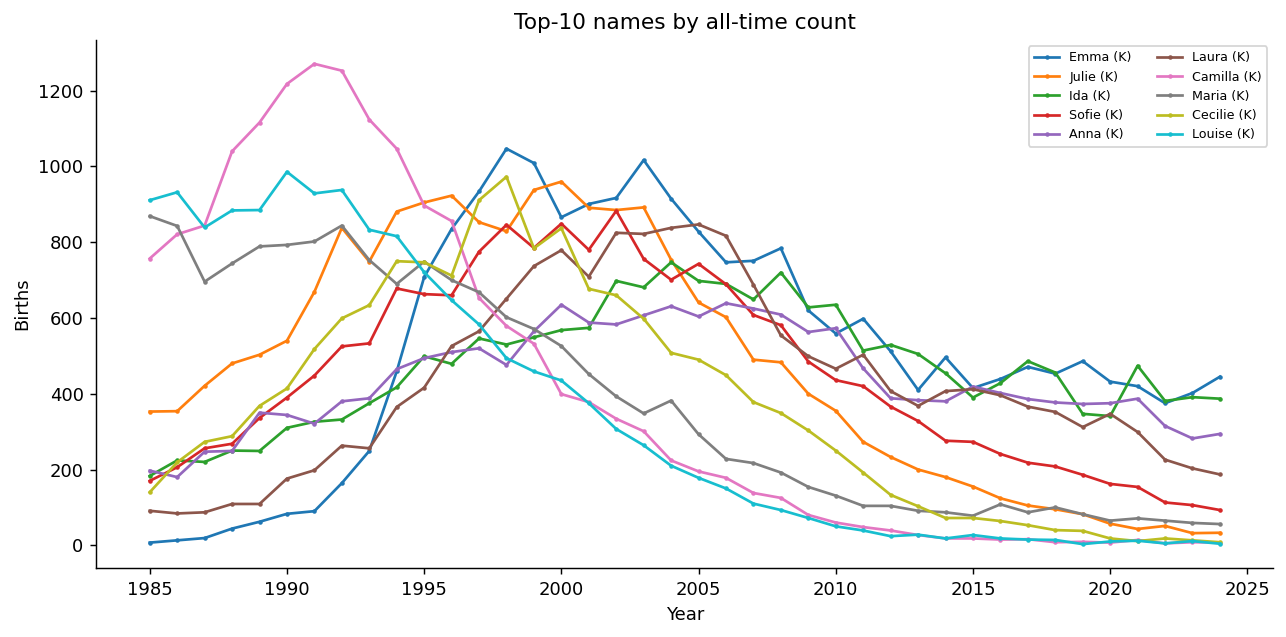

In [4]:
# Top-10 names by total count over all years, plotted as time series
counts = df.copy()
counts["total"] = counts[years].sum(axis=1)
top10 = counts.nlargest(10, "total")

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in top10.iterrows():
    label = f"{row['name']} ({row['gender']})"
    ax.plot(year_ints, row[years].values, marker=".", markersize=3, label=label)
ax.set_title("Top-10 names by all-time count")
ax.set_xlabel("Year")
ax.set_ylabel("Births")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Year-to-year variance (normalized)

In [36]:
# Normalized year-to-year variance:
#   1. Normalize each row to a probability distribution (counts / total).
#   2. Compute variance of the year-to-year *difference* in that distribution.
#      This captures how volatile a name's popularity is, independent of scale.

vals = df[years].values.astype(float)
row_totals = vals.sum(axis=1, keepdims=True)

# Drop names with zero total (unseen names)
mask = row_totals.squeeze() > 0
vals_nz = vals[mask]
totals_nz = row_totals[mask]
df_nz = df[mask].copy()

# Normalised share per year
share = vals_nz / totals_nz          # shape (N, T)

# Year-to-year differences in share
diffs = np.diff(share, axis=1)       # shape (N, T-1)

# Variance of those differences per name
yty_var = diffs.var(axis=1)          # shape (N,)

df_nz = df_nz.reset_index(drop=True)
df_nz["yty_var"] = yty_var

print("Year-to-year normalized variance — top 15 most volatile names:")
display(df_nz[["name", "gender", "yty_var"]].nlargest(15, "yty_var").reset_index(drop=True))

print("Year-to-year normalized variance — top 15 least volatile names:")
display(df_nz[["name", "gender", "yty_var"]].nsmallest(15, "yty_var").reset_index(drop=True))

Year-to-year normalized variance — top 15 most volatile names:


,name,gender,yty_var
0,Conni,K,0.051282
1,Fadime,K,0.051282
2,Anne-lise,K,0.051282
3,Hacer,K,0.051282
4,Solvejg,K,0.051282
5,Lajla,K,0.051282
6,Rukiye,K,0.051282
7,Gül,K,0.051282
8,Songül,K,0.051282
9,Serife,K,0.051282


Year-to-year normalized variance — top 15 least volatile names:


,name,gender,yty_var
0,Anna,K,0.000006
1,Marie,K,0.000006
2,Maja,K,0.000007
3,Maria,K,0.000007
4,Stine,K,0.000007
5,Louise,K,0.000008
6,Ellen,K,0.000009
7,Lea,K,0.000009
8,Ida,K,0.000009
9,Astrid,K,0.000010


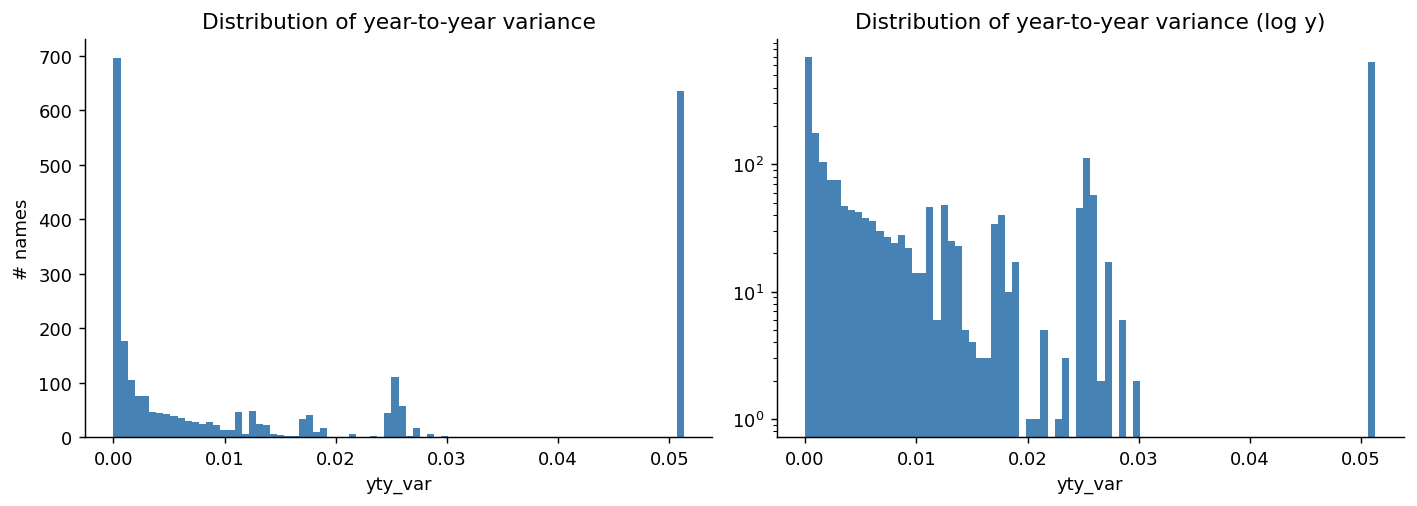

In [6]:
# Distribution of yty_var (log scale to handle the long tail)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_nz["yty_var"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Distribution of year-to-year variance")
axes[0].set_xlabel("yty_var")
axes[0].set_ylabel("# names")

axes[1].hist(df_nz["yty_var"], bins=80, color="steelblue", edgecolor="none", log=True)
axes[1].set_title("Distribution of year-to-year variance (log y)")
axes[1].set_xlabel("yty_var")

plt.tight_layout()
plt.show()

## Entropy across years

In [44]:
# High entropy → popularity spread evenly across years.
# Low entropy  → popularity concentrated in few years.

ent = np.apply_along_axis(
    lambda row: scipy_entropy(row + 1e-12),   # +eps avoids log(0)
    axis=1,
    arr=share,
)
df_nz["entropy"] = ent

max_entropy = np.log(len(years))   # uniform distribution upper bound
df_nz["entropy_norm"] = df_nz["entropy"] / max_entropy

print(f"Max possible entropy (uniform over {len(years)} years): {max_entropy:.3f}")

print("\nLowest entropy (most concentrated):")
display(df_nz[["name", "gender", "entropy_norm", "yty_var"]].nsmallest(10, "entropy_norm").reset_index(drop=True))
print("\nHighest entropy (most spread out):")
display(df_nz[["name", "gender", "entropy_norm", "yty_var"]].nlargest(10, "entropy_norm").reset_index(drop=True))

Max possible entropy (uniform over 40 years): 3.689

Lowest entropy (most concentrated):


,name,gender,entropy_norm,yty_var
0,Solvejg,K,3.026962e-10,0.051282
1,Rukiye,K,3.026962e-10,0.051282
2,Åsa,K,3.026962e-10,0.051282
3,Rannvá,K,3.026962e-10,0.051282
4,Valborg,K,3.026962e-10,0.051282
5,Lilav,K,3.026962e-10,0.051282
6,Aviaaja,K,3.026962e-10,0.051282
7,Rósa,K,3.026962e-10,0.051282
8,Rüya,K,3.026962e-10,0.051282
9,Simav,K,3.026962e-10,0.051282



Highest entropy (most spread out):


,name,gender,entropy_norm,yty_var
0,Lea,K,0.997343,0.000009
1,Marie,K,0.993120,0.000006
2,Lykke,K,0.992993,0.000041
3,Karen,K,0.992283,0.000026
4,Iben,K,0.989781,0.000035
5,Minna,K,0.989319,0.000087
6,Anna,K,0.987808,0.000006
7,Elisabeth,K,0.987393,0.000036
8,Nynne,K,0.986496,0.000026
9,Linea,K,0.985811,0.000042


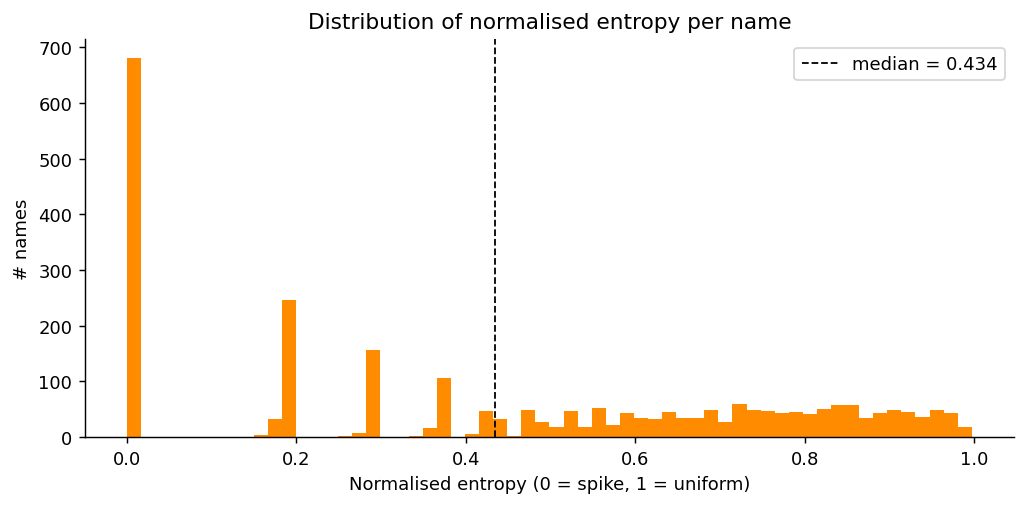

In [10]:
# Distribution of per-name entropy (normalised)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_nz["entropy_norm"], bins=60, color="darkorange", edgecolor="none")
ax.axvline(df_nz["entropy_norm"].median(), color="black", linestyle="--", linewidth=1, label=f"median = {df_nz['entropy_norm'].median():.3f}")
ax.set_title("Distribution of normalised entropy per name")
ax.set_xlabel("Normalised entropy (0 = spike, 1 = uniform)")
ax.set_ylabel("# names")
ax.legend()
plt.tight_layout()
plt.show()

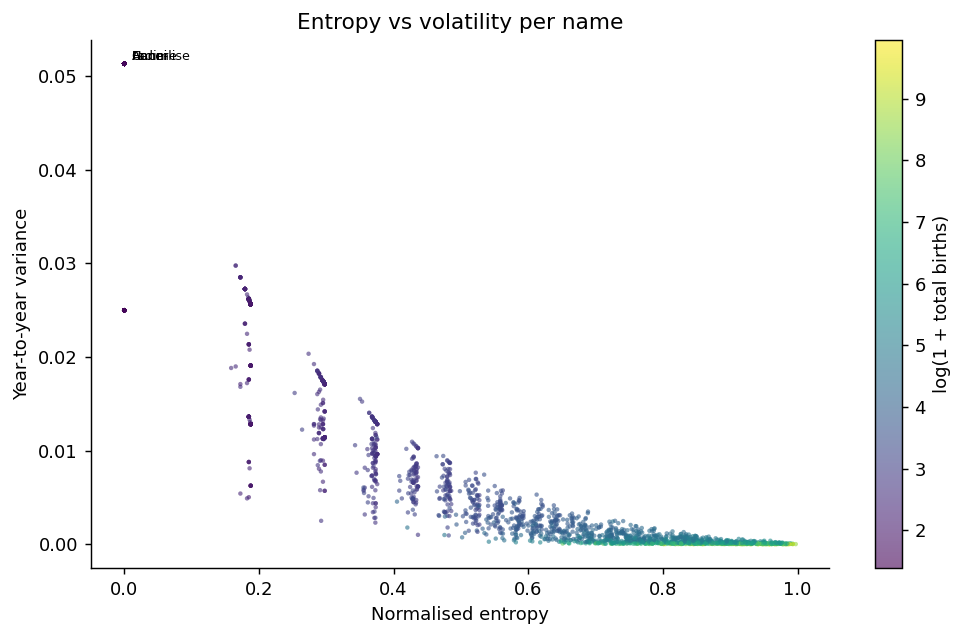

In [11]:
# Scatter: entropy vs yty_var — coloured by log(total births)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    df_nz["entropy_norm"],
    df_nz["yty_var"],
    c=np.log1p(df_nz[years].sum(axis=1)),
    cmap="viridis",
    s=6,
    alpha=0.6,
    linewidths=0,
)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("log(1 + total births)")
ax.set_xlabel("Normalised entropy")
ax.set_ylabel("Year-to-year variance")
ax.set_title("Entropy vs volatility per name")

# Annotate a few extremes
for _, row in df_nz.nlargest(4, "yty_var").iterrows():
    ax.annotate(row["name"], (row["entropy_norm"], row["yty_var"]), fontsize=7,
                xytext=(4, 2), textcoords="offset points")

plt.tight_layout()
plt.show()

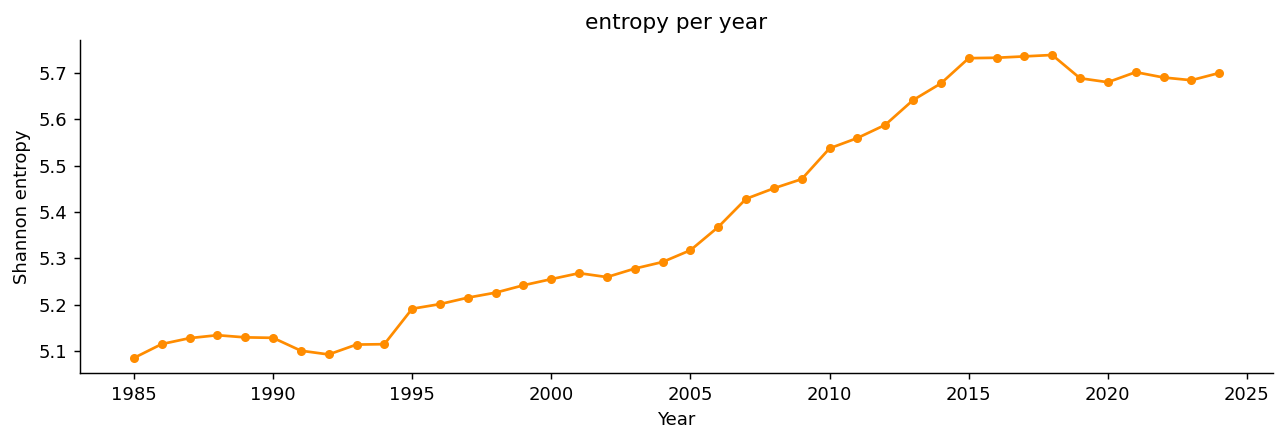

In [28]:
# Aggregate: entropy of the name *pool* per year
# For each year, treat name counts as a distribution over names — how concentrated is naming that year?

yearly_counts = df[years].values.astype(float)          # shape (N, T)
pool_entropy = []
for t in range(len(years)):
    col = yearly_counts[:, t]
    col = col[col > 0]
    pool_entropy.append(scipy_entropy(col))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(year_ints, pool_entropy, color="darkorange", marker="o", markersize=4)
ax.set_title("entropy per year")
ax.set_xlabel("Year")
ax.set_ylabel("Shannon entropy")
plt.tight_layout()
plt.show()

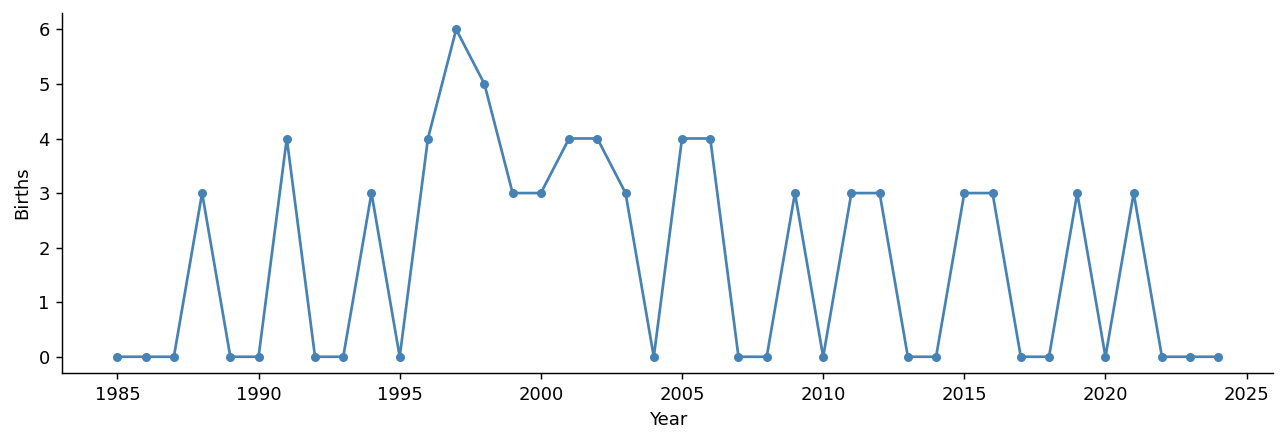

In [71]:
y=df_nz[df_nz.name == 'Manon'][years].values

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(year_ints, y.flatten(), color="steelblue", marker="o", markersize=4)
ax.set_xlabel("Year")
ax.set_ylabel("Births")
plt.tight_layout()
plt.show()


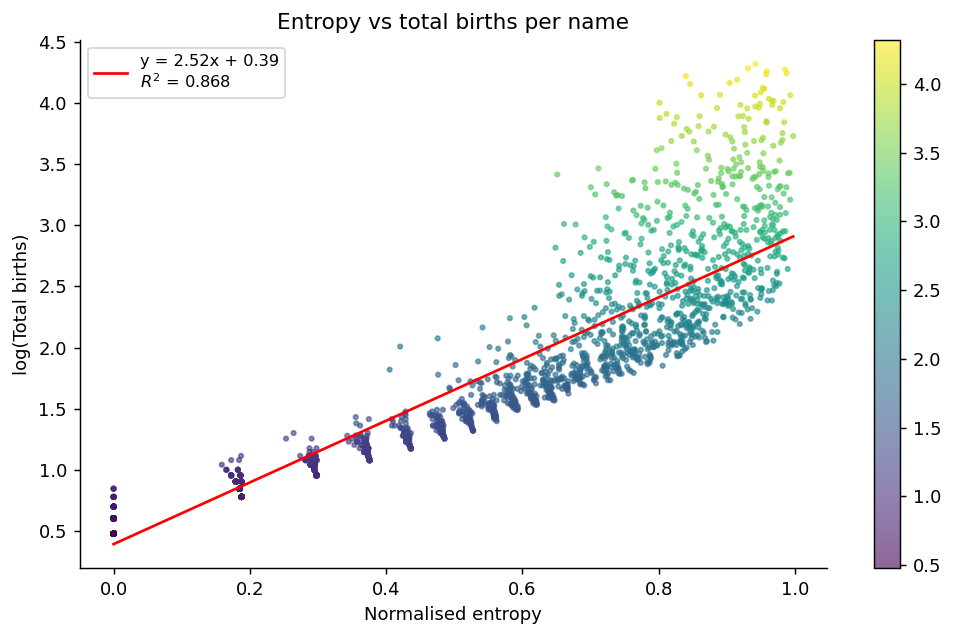

In [66]:
from scipy import stats

df_nz['total'] = df_nz[years].sum(axis=1)

x = df_nz['entropy_norm']
y =  np.log10(df_nz['total'])

# Fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    x, y,
    c=np.log10(df_nz[years].sum(axis=1)),
    cmap="viridis", s=6, alpha=0.6,
)
ax.plot(x_line, y_line, color="red", linewidth=1.5, label=f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.3f}")

cb = plt.colorbar(sc, ax=ax)
ax.set_xlabel("Normalised entropy")
ax.set_ylabel("log(Total births)")
ax.set_title("Entropy vs total births per name")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [69]:
df_nz['y_pred'] = slope * df_nz['entropy_norm'] + intercept
df_nz['residual'] = np.log10(df_nz['total']) - df_nz['y_pred']

# Bottom 10
bottom10 = df_nz.nsmallest(50, 'residual')[['name', 'entropy_norm', 'total', 'residual']]
display(bottom10)

,name,entropy_norm,total,residual
1879,Manon,0.805739,71,-0.574523
277,Dorthea,0.880296,114,-0.557083
637,Helen,0.830934,86,-0.554884
1012,Asli,0.829503,86,-0.551271
359,Sørine,0.827241,85,-0.550640
2176,Paulina,0.869574,111,-0.541598
276,Kristiane,0.870762,113,-0.536844
2296,Sallie,0.834587,93,-0.530120
2064,Nancy,0.763432,62,-0.526594
2293,Salina,0.826509,90,-0.523968
